In [1]:
import pandas as pd
import pymc as pm
import japanize_matplotlib
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import numpy as np
import arviz as az

In [2]:
df = pd.read_csv("../data/telco_churn_survival.csv")
df

,customerID,tenure,Churn,Contract,MonthlyCharges,gender,SeniorCitizen,event
0,7590-VHVEG,1,No,Month-to-month,29.85,Female,0,0
1,5575-GNVDE,34,No,One year,56.95,Male,0,0
2,3668-QPYBK,2,Yes,Month-to-month,53.85,Male,0,1
3,7795-CFOCW,45,No,One year,42.30,Male,0,0
4,9237-HQITU,2,Yes,Month-to-month,70.70,Female,0,1
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,24,No,One year,84.80,Male,0,0
7039,2234-XADUH,72,No,One year,103.20,Female,0,0
7040,4801-JZAZL,11,No,Month-to-month,29.60,Female,0,0
7041,8361-LTMKD,4,Yes,Month-to-month,74.40,Male,1,1


In [8]:
#log0 = ∞を防ぐ
t_obs = df["tenure"].values.astype(float) + 0.5
event_obs = df["event"].values.astype(float)
n = len(df)

In [9]:
with pm.Model() as weibull_model_v0:
    k = pm.Gamma("k", alpha=50, beta=50/0.5)
    lam = pm.Gamma("lam", alpha=50, beta=50/120)

    log_hazard = pt.log(k) + (k-1) * pt.log(t_obs) -k * pt.log(lam)
    log_survival = -pt.pow(t_obs/lam, k)

    log_lik = event_obs * log_hazard + log_survival
    pm.Potential("loglike", pt.sum(log_lik))
    

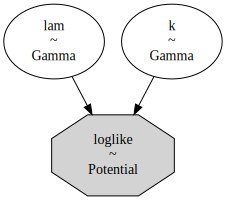

In [10]:
pm.model_to_graphviz(weibull_model_v0)

In [11]:
with weibull_model_v0:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

/tmp/ipykernel_7428/3328484485.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [k, lam]


In [13]:
#カプランマイヤー曲線
def kaplan_meier(t_obs, event_obs):
    order = np.argsort(t_obs)
    t_sorted = t_obs[order]
    e_sorted = event_obs[order]
    unique_times = np.unique(t_sorted[e_sorted == 1])

    survival = 1.0
    km_times= [0]
    km_surv = [1.0]
    n_at_risk = len(t_obs)

    for t in unique_times:
        n_event = np.sum((t_sorted == t) & (e_sorted == 1))
        n_at_risk = np.sum(t_sorted >= t)
        survival *= (1 - n_event / n_at_risk)
        km_times.append(t)
        km_surv.append(survival)

    return np.array(km_times), np.array(km_surv)

km_t, km_s = kaplan_meier(t_obs, event_obs)
    
    

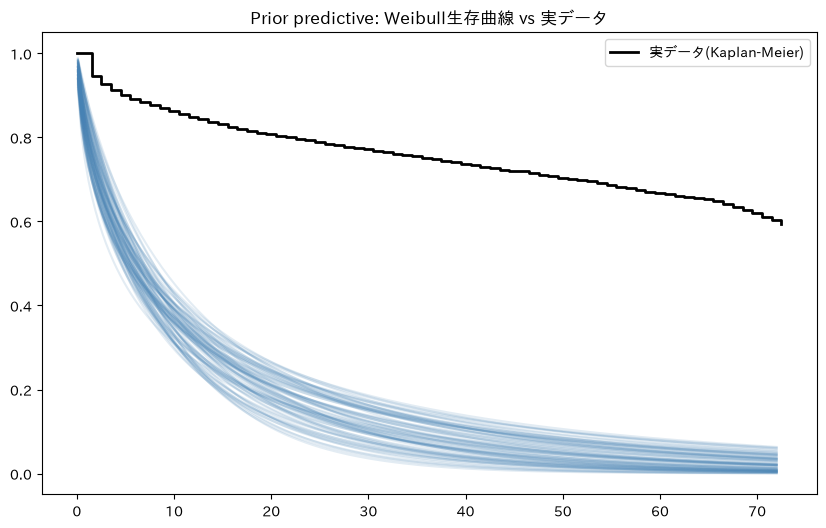

In [44]:
k_prior = prior.prior["k"].values.flatten()
lam_prior = prior.prior["lam"].values.flatten()

t_range = np.linspace(0.1, 72, 200)
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(80):
    S_t = np.exp(-(t_range/lam_prior[i])**k_prior[i])
    ax.plot(t_range, S_t, color="steelblue", alpha=0.15)

ax.step(km_t, km_s, where="post", color="black", lw=2, label="実データ(Kaplan-Meier)")
ax.legend()
ax.set_title("Prior predictive: Weibull生存曲線 vs 実データ")
plt.savefig("../img/weibull_prior_check.png", dpi=100)

In [45]:
with pm.Model() as weibull_model_v1:
    k = pm.Gamma("k", alpha=50, beta=50/0.7)
    lam = pm.Gamma("lam", alpha=50, beta=50/180)

    log_hazard = pt.log(k) + (k-1) * pt.log(t_obs) -k * pt.log(lam)
    log_survival = -pt.pow(t_obs/lam, k)

    log_lik = event_obs * log_hazard + log_survival
    pm.Potential("loglike", pt.sum(log_lik))
    

In [46]:
with weibull_model_v1:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

/tmp/ipykernel_7428/2997583888.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [k, lam]


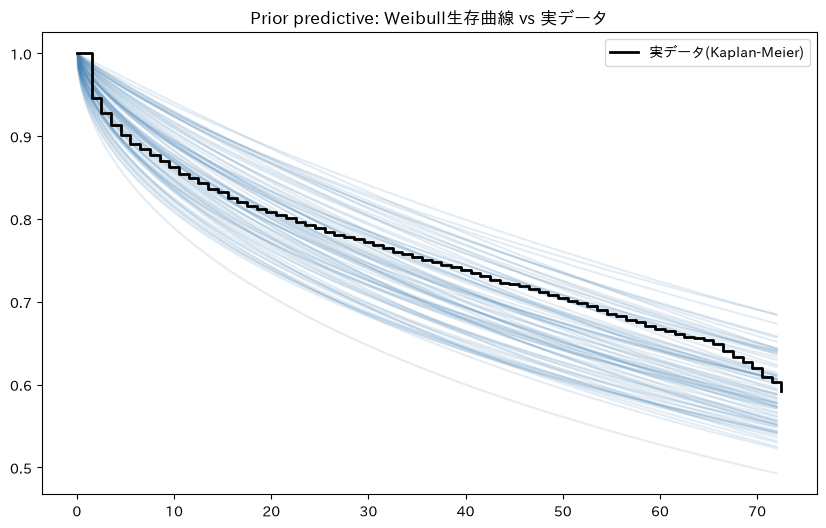

In [47]:
k_prior = prior.prior["k"].values.flatten()
lam_prior = prior.prior["lam"].values.flatten()

t_range = np.linspace(0.1, 72, 200)
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(80):
    S_t = np.exp(-(t_range/lam_prior[i])**k_prior[i])
    ax.plot(t_range, S_t, color="steelblue", alpha=0.15)

ax.step(km_t, km_s, where="post", color="black", lw=2, label="実データ(Kaplan-Meier)")
ax.legend()
ax.set_title("Prior predictive: Weibull生存曲線 vs 実データ")
plt.savefig("../img/weibull_prior_check_v1.png", dpi=100)

In [49]:
with weibull_model_v1:
    idata = pm.sample(draws=2000, tune=2000, chains=4, target_accept=0.90, nuts_sampler="numpyro", random_seed=42)

NUTS[numpyro]: [k, lam]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Compiling.. :   0%|                                     | 0/4000 [00:00<?, ?it/s]

  0%|                                                   | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                     | 0/4000 [00:00<?, ?it/s]


  0%|                                                   | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                  | 0/4000 [00:00<?, ?it/s]

Running chain 2:   0%|                                  | 0/4000 [00:00<?, ?it/s]


Running chain 3:   0%|                                  | 0/4000 [00:00<?, ?it/s]


Running chain 1:   5%|█▏                     | 200/4000 [00:01<00:05, 674.52it/s]

Running chain 2:   5%|█▏                     | 200/4000 [00:01<00:06, 617.60it/s]


Running chain 1:  10%|██▎                    | 400/4000 [00:01<00:04, 894.05it/s]

Running chain 0:  15%|███▎    

In [52]:
print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.summary(idata, var_names=["k", "lam"])

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
k,0.6922,0.0142,0.67,0.71,2652,3314,1.00,0.00028,0.00019
lam,198.9,9.1,180,210,2889,3426,1.00,0.17,0.12


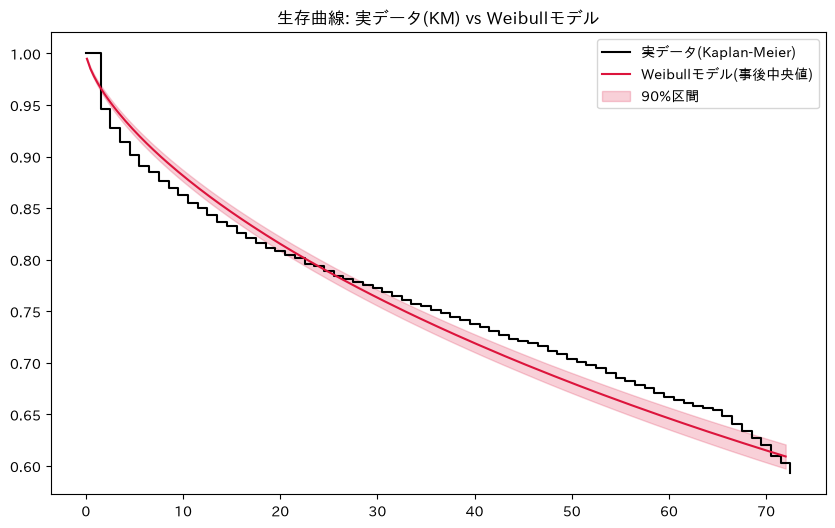

In [53]:
k_post = idata.posterior["k"].values.flatten()
lam_post = idata.posterior["lam"].values.flatten()

t_range = np.linspace(0.1, 72, 200)
S_samples = np.array([np.exp(-(t_range/lam_post[i])**k_post[i]) for i in range(len(k_post))])

S_median = np.median(S_samples, axis=0)
S_lower = np.percentile(S_samples, 5, axis=0)
S_upper = np.percentile(S_samples, 95, axis=0)

fig, ax = plt.subplots(figsize=(10,6))
ax.step(km_t, km_s, where="post", color="black", label="実データ(Kaplan-Meier)")
ax.plot(t_range, S_median, color="crimson", label="Weibullモデル(事後中央値)")
ax.fill_between(t_range, S_lower, S_upper, color="crimson", alpha=0.2, label="90%区間")
ax.legend()
ax.set_title("生存曲線: 実データ(KM) vs Weibullモデル")
plt.savefig("../img/weibull_posterior_check.png", dpi=100)